## Example: Numpy Vectorization and Broadcasting

In [3]:
import numpy as np
import pandas as pd

## Example: Nearest Neighbor Analysis

In materials simulation, we constantly need the distance between pairs of atoms

* atom $A=(a_1,a_2,a_3)$
* atom $B=(b_1,b_2,b_3)$

* Euclidean distance between atoms:
  
 $$D_{\text{Euclidean}}(A,B) = \left(\sum_{i=1}^{3} (a_i-b_i)^2\right)^{1/2}$$

* Ex: $(0,0,0)$, $(0.5,0.5,0.5)$
$$ D = \sqrt{0.5^2+0.5^2+0.5^2} = 0.866$$

## General Definition of Distance between two points (Minkowski Distance)

* For $n$-dimensional points $A=(a_1,\dots,a_n)$, $B=(b_1,\dots,b_n)$:
* Minkowski distance:
  
    $$ D_p(A,B) = \left(\sum_{i=1}^{n} (a_i-b_i)^p\right)^{1/p}$$ 

* Special cases:
    *  $p=2$: Euclidean distance
    *  $p=1$: Manhattan distance

We write code for a general $(p, n)$, so it works for any specific case.

## Pseudocode

The algorithm for distance between atoms in 3D can be written as:

```text
Initialize D_Eucld matrix of size (N, N)
for i = 0 to N-1:
    for j = 0 to N-1:
        # Calculates one distance at a time
        D_Eucld(i,j) = sqrt( (x_i - x_j)^2 + (y_i - y_j)^2 + (z_i - z_j)^2 )
```

## Implementing Euclidean distance estimation in core Python

To demonstrate a simple estimate of Euclidean distance using atomic position as a list 

In [3]:
atom1 = [0., 0., 0.]
atom2 = [0.5, 0.5, 0.5]
p = 2

dx_sq = (atom1[0] - atom2[0])**p
dy_sq = (atom1[1] - atom2[1])**p
dz_sq = (atom1[2] - atom2[2])**p

eucdist_sq = dx_sq + dy_sq + dz_sq
eucdist = eucdist_sq ** (1/p)
eucdist

0.8660254037844386

* Code is easy to interpret and understand
* Gives correct result

## Implementing as a Python function:

In [15]:
def calculate_euclidean_dist_lists(atom1, atom2, p):
    eucdist_sq = []
    for i in range(3):
        eucdist_sq.append((atom1[i] - atom2[i])**p)
    sum_eucdist_sq = sum(eucdist_sq)
    return sum_eucdist_sq**(1/p)

# Test the function
atom1 = [0., 0., 0.]
atom2 = [0.5, 0.5, 0.5]
p = 2

calculate_euclidean_dist_lists(atom1, atom2, p)

0.8660254037844386

## Extended it to more than two atoms

In our toy example, let's consider 4 atoms

In [16]:
def apply_euclidean_distance_forloop(atoms, p):
    dist = []
    for i in range(len(atoms)):
        tmp_dist = []
        for j in range(len(atoms)):
            tmp_dist.append(calculate_euclidean_dist_lists(atoms[i], atoms[j], p))
        dist.append(tmp_dist)

    return dist

# atomic positions as list of lists
atoms = [[0., 0., 0.], [0.5, 0.5, 0.5], [0.5, 0.5, 0.], [0., 0.5, 0.5]]

result = apply_euclidean_distance_forloop(atoms, 2)

import pandas as pd
pd.DataFrame(result)

,0,1,2,3
0,0.000000,0.866025,0.707107,0.707107
1,0.866025,0.000000,0.500000,0.500000
2,0.707107,0.500000,0.000000,0.707107
3,0.707107,0.500000,0.707107,0.000000


* We get a $4 \times 4$ matrix as expected, with entries corresponding to distances between any two atoms
* Diagonal entries are zero (distance of an atom with itself)
* The matrix is symmetric as distance is a scalar it does not depend on relative order $(i,j)$ vs $(j,i)$

## Test our code for larger number of atoms

We upload a Cu (FCC) crystal structure with a much larger number of atoms

We then test how much time it takes to evaluate distance using the simple Python code that we have written using Lists and For loop

In [34]:
cu_atoms = pd.read_csv(
    'Cu_atoms.xyz', 
    sep='\s+',           # Matches any whitespace (spaces or tabs)
    comment='#',         # Skips any line starting with #
    header=None,         # Tells pandas there are no column names in the file
    names=['atom', 'x', 'y', 'z']  # Assigns names directly
)

In [35]:
cu_atoms

,atom,x,y,z
0,Cu,0.000000,0.000000,0.000000
1,Cu,0.000000,0.000000,3.580000
2,Cu,0.000000,0.000000,7.160000
3,Cu,0.000000,0.000000,10.740000
4,Cu,0.000000,0.000000,14.320000
...,...,...,...,...
4626,Cu,34.009999,34.009999,21.480000
4627,Cu,34.009999,34.009999,25.059999
4628,Cu,34.009999,34.009999,28.639999
4629,Cu,34.009999,34.009999,32.219999


* The structure has 4631 atoms
* Each row entry contain atom type and the (x,y,z) coordinates

To apply, we first read the all the atomic coordinates in the structure as a List

And then time the output of your written Python function.

In [29]:
atomslist = cu_atoms[['x', 'y', 'z']].values.tolist()

In [28]:
%time result = apply_euclidean_distance_forloop(atomslist, 2)

CPU times: user 14.3 s, sys: 324 ms, total: 14.6 s
Wall time: 14.7 s


* We have some measure of time now for our core Python code
* Next we see how can we implement the same pseudo code using NumPy

## Implementing using NumPy

Here, we would define the atomic position as a NumPy array

For any material structure, atomic positions can be stored as an $n\times3$ array, one row per atom:

$\begin{bmatrix}
x_1 & y_1 & z_1 \\
x_2 & y_2 & z_2 \\
\vdots & \vdots & \vdots \\
x_n & y_n & z_n
\end{bmatrix}_{n\times 3}$

* Our task: compute the distance between \emph{every} pair of rows.
* For $n$ atoms that means $\frac{n(n-1)}{2}$ pairwise distances
* So we are looking at the order of $\mathcal{O}(n^2)$ operations.

In [4]:
def calculate_euclidean_dist_numpy(atom1, atom2, p):
    eucdist_sq = np.power((atom1 - atom2), p)
    sum_eucdist_sq = sum(eucdist_sq)
    return sum_eucdist_sq**(1/p)

def apply_euclidean_distance_numpy(atoms, p):
    dist = []
    for i in range(len(atoms)):
        tmp_dist = []
        for j in range(len(atoms)):
            tmp_dist.append(calculate_euclidean_dist_numpy(atoms[i], atoms[j], p))
        dist.append(tmp_dist)

    return dist

atoms = np.array([[0., 0., 0.],
                 [0.5, 0.5, 0.5],
                 [0.5, 0.5, 0.],
                 [0., 0.5, 0.5]])

p = 2 

result = apply_euclidean_distance_numpy(atoms, p)

pd.DataFrame(result)

,0,1,2,3
0,0.000000,0.866025,0.707107,0.707107
1,0.866025,0.000000,0.500000,0.500000
2,0.707107,0.500000,0.000000,0.707107
3,0.707107,0.500000,0.707107,0.000000


* We check and find that we get the same result
* We can time the NumPy result on a Cu structure with large number of atoms

In [31]:
atomsarray = cu_atoms[['x', 'y', 'z']].to_numpy()

In [32]:
%time result = apply_euclidean_distance_numpy(atomsarray, 2)

CPU times: user 38.1 s, sys: 344 ms, total: 38.4 s
Wall time: 38.5 s


* We observe that the time taken is similarly in seconds as the core Python code
* It is taking slightly more time for NumPy compared to the walltime of 14.7 sec previously
* However, let us not reach any immediate conclusion about NumPy at present
* We should note that in our code we are still making use of two For Loops

### The Cost of Explicit Loops in Python:

When calculating the pairwise distances for a system of **4,631 atoms** using a standard nested `for` loop, the math scales quadratically ($N \times N$). 

**Total Iterations:** 4,631 × 4,631 = **21,446,161 iterations**


What Python does during *every single one* of those 21.4 million iterations?

* Look up the memory address for i and j.
* Check the data types of the $x, y, z$ coordinates to ensure they can be subtracted.
* Perform the subtraction, square the results, sum them, and take the square root.
* Store the result in the new matrix.


Because Python executes this list of administrative tasks sequentially, step by step, 21.4 million times, the accumulated overhead is massive. While a compiled language like C or Fortran can chew through 21 million simple arithmetic operations in a fraction of a second, standard Python can take significantly longer.

### The Vectorized Solution
By transitioning from these explicit `for` loops to **NumPy broadcasting**, we offload all 21.4 million calculations directly to NumPy's vectorization trick, which can turn a computation that takes minutes into one that takes milliseconds!

To avoid `for` loops in order to iterate over the coordinates for each atom

Let us try to explore how we can make use of NumPy element-by-element subtraction operations which are computationally very fast

Let us first apply it to our toy example of (4,3) array of 4 atoms:

* Suppose we would like to subtract the coordinates of atom1 from the coordinates of all the atoms (including self)
* Imagine we stretch the atoms1 (1,3) array along the rows to make it a (4,3) array
* This will then make the new stretched atom1 array compatible with the original all-atoms (4,3) array
* And we can then perform fast NumPy element-wise subtraction

<img src="./figs/broadcasting_1Dto2D.png" width="800">

In [25]:
atom1 = np.array([0., 0., 0.])

print('atoms - atom1')
atoms - np.array([atom1, atom1, atom1, atom1])

atoms - atom1


array([[0. , 0. , 0. ],
       [0.5, 0.5, 0.5],
       [0.5, 0.5, 0. ],
       [0. , 0.5, 0.5]])

### From 2D array to 3D array

<img src="./figs/elementwise_3d_subtraction.png" width="800">

In [27]:
atom2 = np.array([0.5, 0.5, 0.5])
atom3 = np.array([0.5, 0.5, 0.])
atom4 = np.array([0., 0.5, 0.5])

print('atoms - atom2')
print(atoms - np.array([atom2, atom2, atom2, atom2]),'\n')

print('atoms - atom3')
print(atoms - np.array([atom3, atom3, atom3, atom3]),'\n')

print('atoms - atom4')
print(atoms - np.array([atom4, atom4, atom4, atom4]),'\n')

atoms - atom2
[[-0.5 -0.5 -0.5]
 [ 0.   0.   0. ]
 [ 0.   0.  -0.5]
 [-0.5  0.   0. ]] 

atoms - atom3
[[-0.5 -0.5  0. ]
 [ 0.   0.   0.5]
 [ 0.   0.   0. ]
 [-0.5  0.   0.5]] 

atoms - atom4
[[ 0.  -0.5 -0.5]
 [ 0.5  0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]] 



## Reshape NumPy Array

<img src="./figs/3d_array_reshape.png" width="800">

In [20]:
atoms.reshape(1,4,3)

array([[[0. , 0. , 0. ],
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0. ],
        [0. , 0.5, 0.5]]])

In [19]:
atoms.reshape(4,1,3)

array([[[0. , 0. , 0. ]],

       [[0.5, 0.5, 0.5]],

       [[0.5, 0.5, 0. ]],

       [[0. , 0.5, 0.5]]])

## Broadcasting and Element-wise substraction

<img src="./figs/final_3d_subtraction.png" width="800">

In [21]:
atoms[np.newaxis,:,:] - atoms[:,np.newaxis,:]

array([[[ 0. ,  0. ,  0. ],
        [ 0.5,  0.5,  0.5],
        [ 0.5,  0.5,  0. ],
        [ 0. ,  0.5,  0.5]],

       [[-0.5, -0.5, -0.5],
        [ 0. ,  0. ,  0. ],
        [ 0. ,  0. , -0.5],
        [-0.5,  0. ,  0. ]],

       [[-0.5, -0.5,  0. ],
        [ 0. ,  0. ,  0.5],
        [ 0. ,  0. ,  0. ],
        [-0.5,  0. ,  0.5]],

       [[ 0. , -0.5, -0.5],
        [ 0.5,  0. ,  0. ],
        [ 0.5,  0. , -0.5],
        [ 0. ,  0. ,  0. ]]])

## The Vectorized Solution

In [31]:
def apply_euclidean_distance_vectorised(atoms, p):
    diffs = atoms[np.newaxis,:,:] - atoms[:,np.newaxis,:]
    diffs_sq = np.power(diffs, p)
    return diffs_sq.sum(axis=-1)**(1/p)

atoms = np.array([[0., 0., 0.],
                 [0.5, 0.5, 0.5],
                 [0.5, 0.5, 0.],
                 [0., 0.5, 0.5]])

p = 2 

result = apply_euclidean_distance_vectorised(atoms,p)

pd.DataFrame(result)

,0,1,2,3
0,0.000000,0.866025,0.707107,0.707107
1,0.866025,0.000000,0.500000,0.500000
2,0.707107,0.500000,0.000000,0.707107
3,0.707107,0.500000,0.707107,0.000000


In [36]:
atomsarray = cu_atoms[['x', 'y', 'z']].to_numpy()
%time result = apply_euclidean_distance_vectorised(atomsarray, 2)

CPU times: user 139 ms, sys: 161 ms, total: 300 ms
Wall time: 311 ms


* We observe that the walltime taken has significantly reduced to **milliseconds** with vectorized code
* Code involves no `for loop`
* **Vectorised code** employing NumPy element-wise subtraction (made possible by **Broadcasting**)

## Remove double-counting

* Distance matrix is symmetric. We can easily work with a lower or upper triangular matrix


In [43]:
atoms = np.array([[0., 0., 0.],
                 [0.5, 0.5, 0.5],
                 [0.5, 0.5, 0.],
                 [0., 0.5, 0.5]])

print('shape', atoms.shape)

n = atoms.shape[0]
print('n =',n)

row_indices, column_indices = np.triu_indices(n, k = 1)

print('printing unique (i,j) \n')

pd.DataFrame({
    "row_indices": row_indices,
    "column_indices": column_indices
})

shape (4, 3)
n = 4
printing unique (i,j) 



,row_indices,column_indices
0,0,1
1,0,2
2,0,3
3,1,2
4,1,3
5,2,3


In [44]:
def apply_euclidean_distance_unique_vectorised(atoms, p):
    n = atoms.shape[0]
    row_i, col_j = np.triu_indices(n, k = 1)
    diffs = atoms[row_i] - atoms[col_j]
    diffs_sq = np.power(diffs, p)
    return diffs_sq.sum(axis=-1)**(1/p)


atoms = np.array([[0., 0., 0.],
                 [0.5, 0.5, 0.5],
                 [0.5, 0.5, 0.],
                 [0., 0.5, 0.5]])

p = 2 

result = apply_euclidean_distance_unique_vectorised(atoms,p)

pd.DataFrame({
    "row_indices": row_indices,
    "column_indices": column_indices,
    "euclidean dist": result
})

,row_indices,column_indices,euclidean dist
0,0,1,0.866025
1,0,2,0.707107
2,0,3,0.707107
3,1,2,0.500000
4,1,3,0.500000
5,2,3,0.707107


In [45]:
atomsarray = cu_atoms[['x', 'y', 'z']].to_numpy()
%time result = apply_euclidean_distance_unique_vectorised(atomsarray, 2)

CPU times: user 290 ms, sys: 140 ms, total: 430 ms
Wall time: 431 ms


## Walltime comparison of Native Python code (with Lists-For-Loops) vs NumPy Vectiorised code

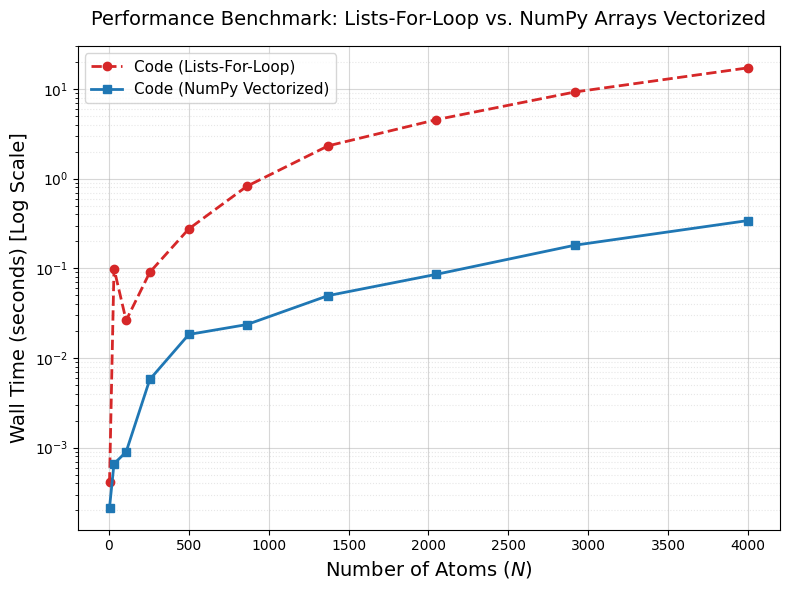

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Exact data from your file
atoms = [4, 32, 108, 256, 500, 864, 1372, 2048, 2916, 4000]
code1_walltime = [0.000409, 0.0995, 0.0262, 0.0903, 0.275, 0.823, 2.32, 4.54, 9.25, 17.2]
code2_walltime = [0.000214, 0.000661, 0.000897, 0.00576, 0.0183, 0.0236, 0.0496, 0.0856, 0.181, 0.341]

# Set up the plot
plt.figure(figsize=(8, 6), dpi=100)

# Plotting with distinct markers and styles
plt.plot(atoms, code1_walltime, marker='o', linestyle='--', linewidth=2, 
         label='Code (Lists-For-Loop)', color='#d62728')
plt.plot(atoms, code2_walltime, marker='s', linestyle='-', linewidth=2, 
         label='Code (NumPy Vectorized)', color='#1f77b4')

# Formatting for academic clarity
plt.yscale('log')
plt.title("Performance Benchmark: Lists-For-Loop vs. NumPy Arrays Vectorized", fontsize=14, pad=15)
plt.xlabel("Number of Atoms ($N$)", fontsize=14)
plt.ylabel("Wall Time (seconds) [Log Scale]", fontsize=14)

# Grid setup for log scale
plt.grid(True, which="major", linestyle='-', alpha=0.5)
plt.grid(True, which="minor", linestyle=':', alpha=0.3)

plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig("performance_benchmark.png", dpi=300, bbox_inches='tight')

plt.show()